<a href="https://colab.research.google.com/github/Nam19ti/ML/blob/main/Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv('spam.csv', encoding='latin1')

In [ ]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5221,ham,"Jane babes not goin 2 wrk, feel ill after lst ...",NaN,NaN,NaN
5495,ham,"Good afternoon, my love ... How goes your day ...",NaN,NaN,NaN
3836,ham,Early bird! Any purchases yet?,NaN,NaN,NaN
4668,ham,"When I was born, GOD said, \Oh No! Another IDI...",GOD said,"\""OH No! COMPETITION\"". Who knew","one day these two will become FREINDS FOREVER!"""
5226,ham,Prabha..i'm soryda..realy..frm heart i'm sory,NaN,NaN,NaN


In [ ]:
df.shape

(5572, 5)

## 1. Data Cleaning

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


- **Cột thừa**: các cột `Unnamed` không có giá trị phân tích.


In [ ]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [ ]:
df.sample(5)

,v1,v2
167,ham,"Hi frnd, which is best way to avoid missunders..."
201,ham,Hello darlin ive finished college now so txt m...
3144,ham,I.ll get there tomorrow and send it to you
130,ham,I'm home.
2081,ham,I'm aight. Wat's happening on your side.


- **Tên cột không rõ ràng**: `v1`, `v2` → cần đổi thành `target`, `text` để dễ đọc.

In [ ]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
2873,ham,Crucify is c not s. You should have told me ea...
2418,ham,"Madam,regret disturbance.might receive a refer..."
1959,ham,Howz that persons story
3586,ham,Our ride equally uneventful - not too many of ...
3622,ham,"Damn, poor zac doesn't stand a chance"


###  Label Encoding — Mã hóa nhãn

`LabelEncoder` chuyển nhãn dạng chuỗi thành số nguyên:

$$\text{ham} \rightarrow 0, \quad \text{spam} \rightarrow 1$$



In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [ ]:
df['target'] = encoder.fit_transform(df['target'])

In [ ]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


- **Kiểm tra giá trị NaN**

In [ ]:

df.isnull().sum()

,0
target,0
text,0


**Kiểm tra bản ghi trùng lặp**

In [ ]:
# check for duplicate values
df.duplicated().sum()

np.int64(403)

In [ ]:
# remove duplicates
df = df.drop_duplicates(keep='first')

In [ ]:
df.duplicated().sum()

np.int64(0)

Xóa bản ghi trùng lặp giúp tránh data leakage — mô hình "nhớ" dữ liệu test nếu cùng một mẫu xuất hiện ở cả train và test set.

In [ ]:
df.shape

(5169, 2)

## 2.EDA

In [ ]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df['target'].value_counts()

,count
target,
0,4516
1,653


#Tỷ lệ giữa tin nhắn thường (ham) và tin nhắn rác (spam)

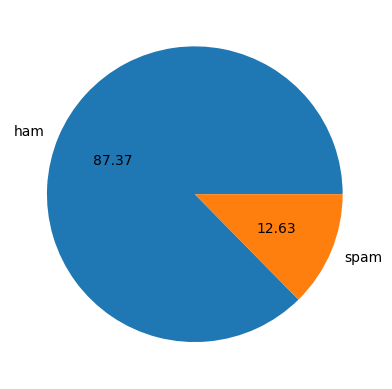

In [ ]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham','spam'],autopct="%0.2f")
plt.show()

Dữ liệu bị mất cân bằng (imbalanced data): khoảng 87.37% là tin thường và 12.63% là spam

Mô hình có xu hướng dự đoán ham cho mọi mẫu để đạt accuracy ~87%

 Cần dùng Precision, Recall, Fβ thay vì chỉ dùng Accuracy

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

> Trong bài toán spam, ta ưu tiên Precision cao để tránh đánh nhầm ham thành spam (False Positive).


In [ ]:
import nltk  # Thư viện xử lý ngôn ngữ tự nhiên
nltk.download('punkt') # Tải bộ tách từ và câu
nltk.download('punkt_tab') # Tải dữ liệu bổ sung cho punkt

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
df['num_characters'] = df['text'].apply(len)
#Tạo cột mới num_characters chứa số ký tự của mỗi tin nhắn/email trong cột text.

In [ ]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [ ]:
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))
# Tạo cột num_words chứa số từ trong mỗi tin nhắn/email.

In [ ]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [ ]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))
# Tạo cột num_sentences chứa số câu trong mỗi tin nhắn/email.

In [ ]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [ ]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [ ]:
# ham
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [ ]:
#spam
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


Một tin nhắn spam có thể chứa số lượng ký tự, số từ và số câu trung bình cao hơn nhiều so với tin nhắn thông thường

### 📊 So sánh thống kê mô tả: Ham vs Spam

Từ kết quả `.describe()` ở trên, ta có thể tổng hợp so sánh các đặc trưng thống kê:

| Đặc trưng | Ham (trung bình) | Spam (trung bình) | Tỷ lệ chênh lệch |
|-----------|-----------------|-------------------|-----------------|
| `num_characters` | ~71 ký tự | ~139 ký tự | **~2× dài hơn** |
| `num_words` | ~15 từ | ~28 từ | **~2× nhiều hơn** |
| `num_sentences` | ~1–2 câu | ~2–4 câu | ~2× nhiều hơn |

> 💡 **Nhận xét**: Tin nhắn spam trung bình **dài gần gấp đôi** tin nhắn bình thường. Điều này phản ánh xu hướng spam thường đính kèm nhiều thông tin lôi kéo, khuyến mãi, URL.


In [ ]:
import seaborn as sns

#Biểu đồ phân phối của độ dài ký tự giữa hai nhóm ham và spam

<Axes: xlabel='num_characters', ylabel='Count'>

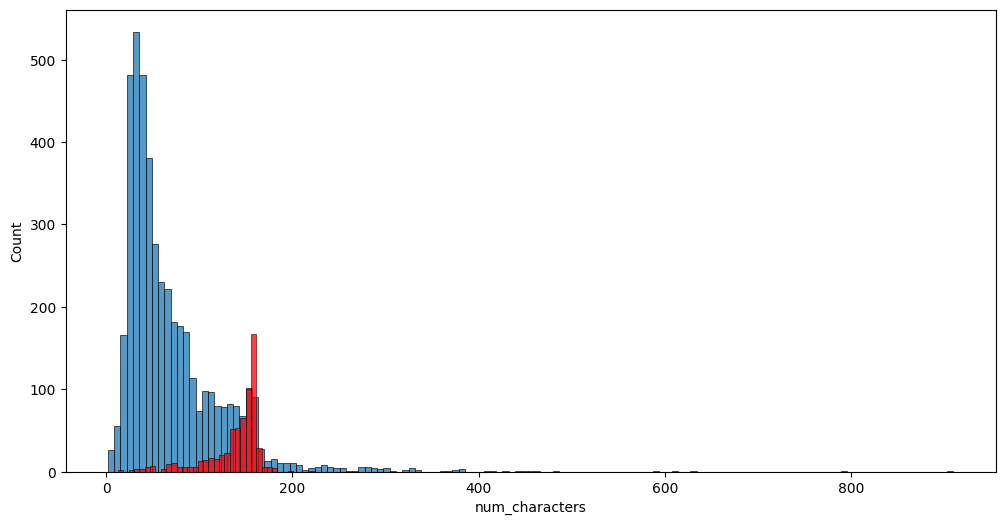

In [ ]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'],color='red')

### 🔍 Phân tích biểu đồ phân phối `num_characters`

Biểu đồ histogram trên (màu **xanh = ham**, màu **đỏ = spam**) cho thấy:

- **Ham** có phân phối **lệch phải mạnh** — đỉnh tập trung ở 0–80 ký tự, rất ít tin dài hơn 150 ký tự.
- **Spam** có phân phối **rải rộng hơn nhiều** — phần lớn nằm trong khoảng 100–200 ký tự.

➡️ **`num_characters` là đặc trưng phân tách ranh giới ham/spam rõ ràng nhất** trong số 3 đặc trưng tạo ra.

Ranh giới phân tách (threshold) sơ bộ có thể đặt ở khoảng **~100 ký tự**:
- Tin nhắn có ít hơn 100 ký tự → rất có khả năng là **ham**
- Tin nhắn dài hơn 100 ký tự → nghi ngờ là **spam** (xác suất cao hơn đáng kể)

> ⚙️ Đây chính là lý do mà trong Heatmap tương quan, `num_characters` có hệ số tương quan **0.38** với `target` — cao nhất trong 3 đặc trưng số.


<Axes: xlabel='num_words', ylabel='Count'>

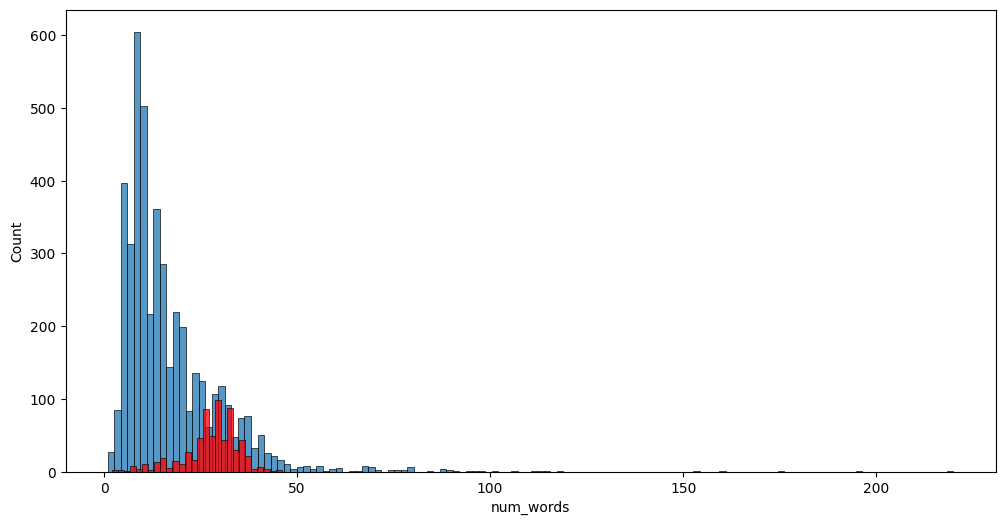

In [ ]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'],color='red')

### 🔍 Phân tích biểu đồ phân phối `num_words`

- **Ham**: phần lớn dưới **20 từ** — tin nhắn ngắn gọn, đời thường.
- **Spam**: phân phối rộng hơn, trung bình **~28 từ**, nhiều tin nhắn lên đến 50–70 từ.

Mặc dù `num_words` cũng cho thấy sự khác biệt giữa 2 nhóm, nhưng **mức độ chồng lấp giữa hai phân phối lớn hơn** so với `num_characters`.

> 📌 **Kết luận từ cả 2 biểu đồ**:  
> Thứ tự phân tách ranh giới từ tốt nhất → kém nhất:  
> **`num_characters`** > **`num_words`** > **`num_sentences`**


 # Mối quan hệ giữa các biến

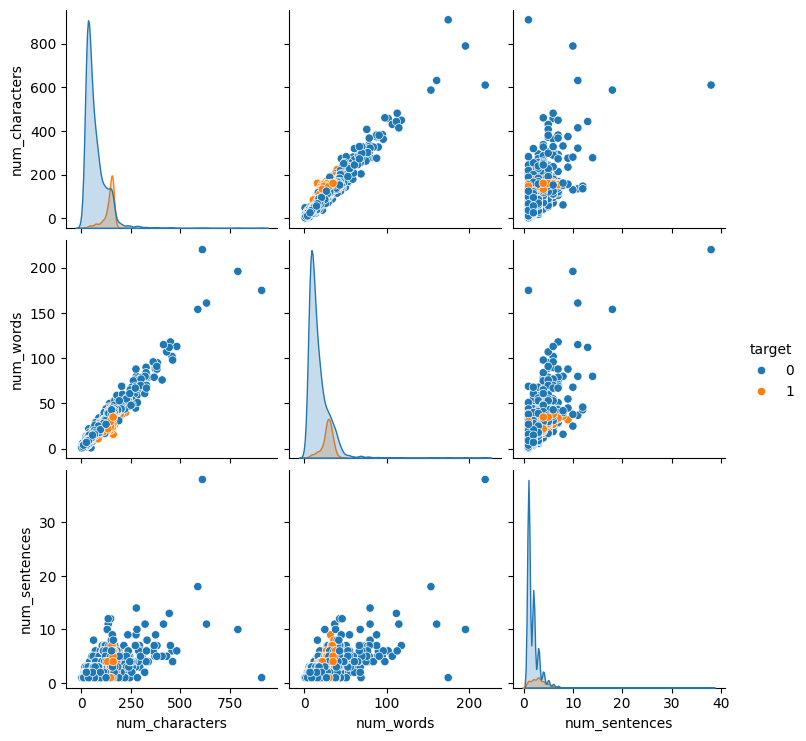

In [ ]:
sns.pairplot(df,hue='target')

<Axes: >

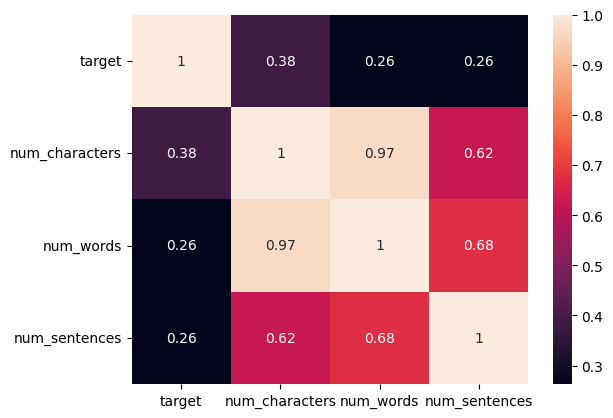

In [ ]:
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True
)

- 3 đặc trưng mới (num_characters, num_words, num_sentences) đều có tương quan dương với biến target (1 là spam) -> các chỉ số này tăng lên, khả năng tin nhắn đó là spam cũng tăng theo
- num_characters và num_words có hệ số tương quan lên tới 0.97 -> chứa nhiều thông tin tương đồng nhau.
- chọn cột num_characters làm đại diện chính vì nó có hệ số tương quan tốt nhất với biến mục tiêu (0.38) so với các cột còn lại

### 📐 Công thức Hệ số tương quan Pearson

Heatmap sử dụng **Pearson Correlation Coefficient (r)**:

$$r(X, Y) = \frac{\sum_{i=1}^{n}(X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum_{i=1}^{n}(X_i - \bar{X})^2} \cdot \sqrt{\sum_{i=1}^{n}(Y_i - \bar{Y})^2}}$$

Giá trị của $r$ nằm trong $[-1, +1]$:
- $r \approx +1$: tương quan thuận mạnh
- $r \approx 0$: không có tương quan tuyến tính
- $r \approx -1$: tương quan nghịch mạnh

**Đọc kết quả Heatmap**:
- `num_characters` ↔ `num_words`: $r = 0.97$ → **gần như cùng mang một thông tin** → có thể chỉ cần giữ 1 trong 2.
- `num_characters` ↔ `target`: $r = 0.38$ → tương quan dương rõ ràng → spam dài hơn ham.
- `num_sentences` ↔ `target`: $r$ thấp hơn → đặc trưng kém phân biệt hơn.

> 📌 **Lựa chọn đặc trưng**: Giữ `num_characters` làm đại diện vì có tương quan với `target` cao nhất.


## 3. Data Preprocessing
- Lower case
- Tokenization
- Removing special characters
- Removing stop words and punctuation
- Stemming

### 🔄 Mục đích của Text Preprocessing

Văn bản thô không thể đưa trực tiếp vào mô hình ML vì:
- Từ viết hoa/thường tạo ra từ điển thừa ("Hello" ≠ "hello")
- Ký tự đặc biệt, dấu câu không mang nghĩa phân loại
- Stop words ("is", "the", "a") xuất hiện ở cả spam lẫn ham → gây nhiễu
- Các biến thể của cùng một từ gốc ("running", "ran", "runs" → "run")

**Pipeline tiền xử lý văn bản (5 bước)**:

```
Văn bản gốc
    ↓ (1) Lowercase — chuyển thường
    ↓ (2) Tokenization — tách thành danh sách từ
    ↓ (3) Loại ký tự đặc biệt — chỉ giữ chữ/số
    ↓ (4) Loại Stop Words & dấu câu
    ↓ (5) Stemming — đưa về gốc từ (PorterStemmer)
Văn bản đã xử lý (clean tokens)
```


In [ ]:
import string
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.stem.porter import PorterStemmer
def transform_text(text):
    text = text.lower() #Chuyển về chữ thường
    text = nltk.word_tokenize(text) #Tách từ

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()
#loại bỏ dấu câu và ký tự đặc biệt, chỉ giữ chữ và số
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()
#loại bỏ các từ ít ý nghĩa như: a, an, the, is, of,...
    for i in text:
        y.append(ps.stem(i))
#đưa từ về dạng nguyên thể

    return " ".join(y)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


### 🔬 Giải thích chi tiết từng bước trong `transform_text()`

**Bước 1 — Lowercase**:
```python
text = text.lower()
# "FREE Prize!" → "free prize!"
```
Mục đích: Thống nhất từ điển — "Prize" và "prize" là cùng một từ.

---

**Bước 2 — Tokenization (Word Tokenize)**:
```python
text = nltk.word_tokenize(text)
# "free prize!" → ["free", "prize", "!"]
```
Tách chuỗi thành danh sách token. `nltk.word_tokenize` xử lý được viết tắt như "don't" → ["do", "n't"].

---

**Bước 3 — Loại bỏ ký tự đặc biệt** (`isalnum()`):
```python
y = [i for i in text if i.isalnum()]
# ["free", "prize", "!"] → ["free", "prize"]
```

---

**Bước 4 — Loại Stop Words**:

Stop words là các từ tần suất cao nhưng ít mang ý nghĩa phân biệt:
> {"i", "me", "my", "a", "an", "the", "is", "in", "it", ...} (153 từ trong tiếng Anh)

---

**Bước 5 — Stemming (Porter Stemmer)**:

Porter Stemmer áp dụng một tập quy tắc hậu tố (suffix-stripping rules):

| Từ gốc | Sau stemming |
|--------|-------------|
| "running" | "run" |
| "winner" | "winner" |
| "prizes" | "prize" |
| "calling" | "call" |
| "discount" | "discount" |

> ⚠️ Stemming đôi khi tạo ra từ không có trong từ điển ("studies" → "studi"), nhưng vẫn hiệu quả vì mô hình học theo **thống kê xuất hiện**, không theo nghĩa.


In [ ]:
ps = PorterStemmer()
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [ ]:
df['transformed_text'] = df['text'].apply(transform_text)

In [ ]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [ ]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [ ]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

# Tần suất xuất hiện từ trong tin nhắn Spam

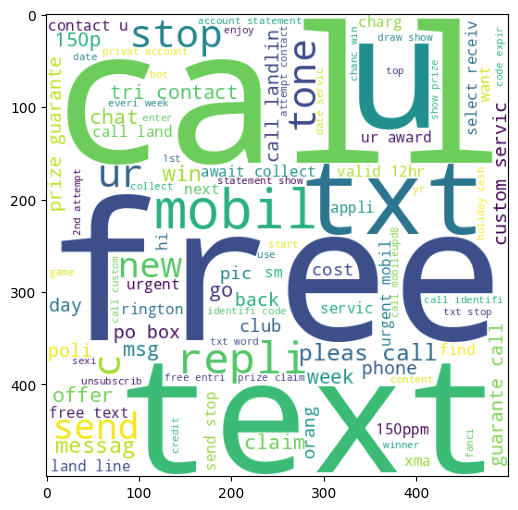

In [ ]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

Tin nhắn spam thường chứa các từ khóa đặc trưng nhằm mục đích lôi kéo người dùng như: "call", "free", "offer", "prize", "text", "urgent"

In [ ]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

# Tần suất xuất hiện từ trong tin nhắn Ham

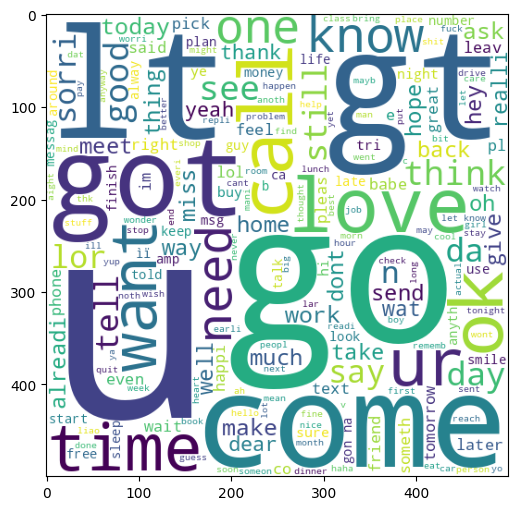

In [ ]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

Tin nhắn thường, các từ xuất hiện phổ biến hơn mang tính giao tiếp đời thường như: "go", "come", "got", "love",...

In [ ]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [ ]:
# Tạo danh sách chứa tất cả từ trong các tin nhắn spam
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)


In [ ]:
len(spam_corpus)

9939

# Các từ xuất hiện nhiều nhất trong tin nhắn spam

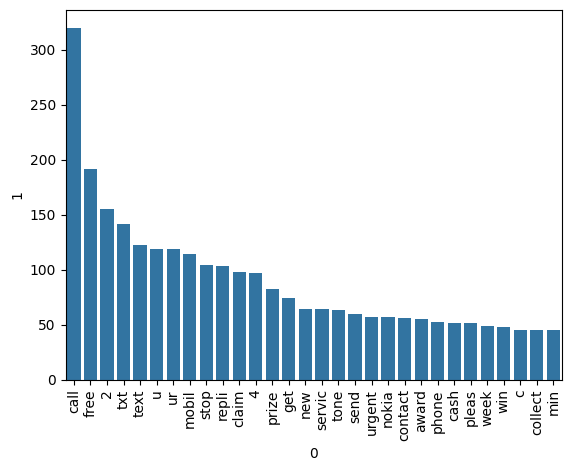

In [ ]:
from collections import Counter

df_temp = pd.DataFrame(Counter(spam_corpus).most_common(30))

sns.barplot(
    x=df_temp[0],
    y=df_temp[1]
)

plt.xticks(rotation='vertical')
plt.show()

In [ ]:
# Tạo danh sách chứa tất cả từ trong các tin nhắn ham
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [ ]:
len(ham_corpus)

35404

# Các từ xuất hiện nhiều nhất trong tin nhắn ham

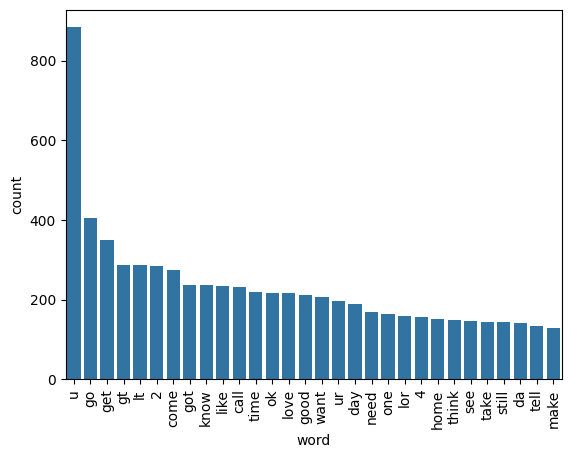

In [ ]:
from collections import Counter

ham_df = pd.DataFrame(
    Counter(ham_corpus).most_common(30),
    columns=['word', 'count']
)

sns.barplot(
    data=ham_df,
    x='word',
    y='count'
)

plt.xticks(rotation=90)
plt.show()

In [ ]:

df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


## 4. Model Building

### Biểu diễn văn bản dạng số — Text Vectorization

Mô hình ML không đọc được văn bản — cần chuyển thành **vector số**. Có hai phương pháp phổ biến:

#### 1. Bag of Words (BoW) — `CountVectorizer`
Mỗi văn bản được biểu diễn bằng **vector đếm số lần xuất hiện** của từng từ trong từ điển:

$$\text{BoW}(d) = [c_1, c_2, ..., c_V]$$

Trong đó $c_i$ là số lần từ $w_i$ xuất hiện trong văn bản $d$, $V$ là kích thước từ điển.

**Hạn chế**: Từ xuất hiện nhiều như "the", "is" sẽ có trọng số cao dù không mang nghĩa → TF-IDF giải quyết điều này.

#### 2. TF-IDF — `TfidfVectorizer`

$$\text{TF}(t, d) = \frac{\text{số lần } t \text{ xuất hiện trong } d}{\text{tổng số từ trong } d}$$

$$\text{IDF}(t) = \log\left(\frac{1 + N}{1 + \text{df}(t)}\right) + 1$$

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

Trong đó:
- $N$: tổng số văn bản trong corpus
- $\text{df}(t)$: số văn bản chứa từ $t$

**Ý nghĩa**: Từ xuất hiện nhiều trong một văn bản nhưng hiếm trong toàn corpus → có TF-IDF cao → **từ đặc trưng phân loại tốt**.

> Ví dụ: từ **"free"** xuất hiện nhiều trong spam nhưng ít trong ham → TF-IDF cao trong spam → đặc trưng phân loại rõ ràng.


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

Công thức TF-IDF

- TF-IDF(t,d)=TF(t,d)×IDF(t)

Trong đó:

- TF (Term Frequency): số lần từ xuất hiện trong văn bản.
- IDF (Inverse Document Frequency): mức độ hiếm của từ trong toàn bộ tập dữ liệu.

TF-IDF không chỉ đếm số lần xuất hiện của từ mà còn đánh giá mức độ quan trọng của từ trong toàn bộ tập dữ liệu. Điều này giúp mô hình tập trung vào các từ đặc trưng của email spam và thường cho kết quả tốt hơn Bag of Words.

In [ ]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [ ]:
X.shape

(5169, 3000)

In [ ]:
y = df['target'].values

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [ ]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,fbeta_score

* Gaussian Naive Bayes: dùng cho các đặc trưng là biến liên tục (ví dụ: chiều cao, cân nặng, giá trị pixel)
*  Multinomial Naive Bayes: dùng cho các đặc trưng là biến đếm (count)
* Bernoulli Naive Bayes: dùng cho các đặc trưng là biến nhị phân (0 hoặc 1)
# -> Multinomial Naive Bayes phù hợp cho bài toán phân loại văn bản

In [ ]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

Dữ liệu bị mất cân bằng (imbalanced data), nên Accuracy (độ chính xác) không phải là thước đo đáng tin cậy nhất.
Tập trung vào chỉ số Precision (Độ chính xác của việc dự báo spam)
- Mục tiêu là tối đa hóa Precision để tránh việc tin nhắn bình thường (ham) bị hệ thống nhầm lẫn đánh dấu là spam (giảm thiểu False Positives).

In [ ]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))
print(recall_score(y_test,y_pred2))
print(fbeta_score(y_test, y_pred2, beta=0.5))

0.9709864603481625
[[896   0]
 [ 30 108]]
1.0
0.782608695652174
0.9473684210526315


In [ ]:
from sklearn.metrics import fbeta_score, recall_score

def train_classifier_with_fbeta(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred) # Calculate recall score
    # Calculate F0.5-score, giving more weight to precision
    f0_5_score = fbeta_score(y_test, y_pred, beta=0.5)

    return accuracy, precision, recall, f0_5_score

In [ ]:
# tfidf --> MNB

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [ ]:
svc = SVC(kernel='sigmoid', gamma=1.0)
mnb = MultinomialNB()
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [ ]:
clfs = {
    'SVC' : svc,
    'NB': mnb,
    'LR': lrc,
    'RF': rfc,
    'xgb':xgb
}

In [ ]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)

    return accuracy,precision

###  Công thức F$\beta$-Score

$$F_{\beta} = (1 + \beta^2) \cdot \frac{\text{Precision} \times \text{Recall}}{\beta^2 \cdot \text{Precision} + \text{Recall}}$$

Trong đó:
- **Precision** = $\frac{TP}{TP + FP}$ — Trong số những tin bị đánh dấu spam, bao nhiêu cái thực sự là spam?
- **Recall** = $\frac{TP}{TP + FN}$ — Trong số tất cả spam thực tế, mô hình phát hiện được bao nhiêu?

**Ý nghĩa của $\beta$:**


>  **Trong bài này**, ta dùng **F0.5-Score** ($\beta = 0.5$) vì chi phí của **False Positive** (ham bị đánh dấu spam khiến người dùng mất tin nhắn quan trọng) cao hơn **False Negative** (một vài spam lọt qua).


In [ ]:
from sklearn.metrics import fbeta_score, recall_score

def train_classifier_with_fbeta(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f0_5_score = fbeta_score(y_test, y_pred, beta=0.5)

    return accuracy, precision, recall, f0_5_score

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

svc = SVC(kernel='sigmoid', gamma=1.0)
mnb = MultinomialNB()
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

clfs = {
    'SVC' : svc,
    'NB': mnb,
    'LR': lrc,
    'RF': rfc,
    'xgb':xgb
}

accuracy_scores_fbeta = []
precision_scores_fbeta = []
recall_scores_fbeta = []
f0_5_scores = []

for name, clf in clfs.items():
    current_accuracy, current_precision, current_recall, current_f0_5_score = train_classifier_with_fbeta(clf, X_train, y_train, X_test, y_test)

    print(f"For {name}")
    print(f"Accuracy - {current_accuracy}")
    print(f"Precision - {current_precision}")
    print(f"Recall - {current_recall}")
    print(f"F0.5-Score - {current_f0_5_score}")
    print("\n")

    accuracy_scores_fbeta.append(current_accuracy)
    precision_scores_fbeta.append(current_precision)
    recall_scores_fbeta.append(current_recall)
    f0_5_scores.append(current_f0_5_score)

For SVC
Accuracy - 0.9758220502901354
Precision - 0.9747899159663865
Recall - 0.8405797101449275
F0.5-Score - 0.9446254071661238


For NB
Accuracy - 0.9709864603481625
Precision - 1.0
Recall - 0.782608695652174
F0.5-Score - 0.9473684210526315


For LR
Accuracy - 0.9555125725338491
Precision - 0.96
Recall - 0.6956521739130435
F0.5-Score - 0.8921933085501859


For RF
Accuracy - 0.9738878143133463
Precision - 0.9826086956521739
Recall - 0.8188405797101449
F0.5-Score - 0.9448160535117057


For xgb
Accuracy - 0.9680851063829787
Precision - 0.9487179487179487
Recall - 0.8043478260869565
F0.5-Score - 0.9158415841584159




In [ ]:

performance_df_fbeta = pd.DataFrame({
    'Algorithm': clfs.keys(),
    'Accuracy': accuracy_scores_fbeta,
    'Precision': precision_scores_fbeta,
    'Recall': recall_scores_fbeta,
    'F0.5_Score': f0_5_scores
}).sort_values('F0.5_Score', ascending=False)

display(performance_df_fbeta)

,Algorithm,Accuracy,Precision,Recall,F0.5_Score
1,NB,0.970986,1.000000,0.782609,0.947368
3,RF,0.973888,0.982609,0.818841,0.944816
0,SVC,0.975822,0.974790,0.840580,0.944625
4,xgb,0.968085,0.948718,0.804348,0.915842
2,LR,0.955513,0.960000,0.695652,0.892193



Thuật toán nào cân bằng tốt nhất giữa Precision cao và Recall hợp lý sẽ đứng đầu.

**Mô hình lý tưởng** cho bài toán spam:
1. **Precision = 1.0** (không có ham nào bị nhầm thành spam)
2. **Recall cao** (phát hiện được nhiều spam nhất có thể)
3. **F0.5 cao** (kết hợp cả hai với trọng số nghiêng về Precision)


In [ ]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9758220502901354, 0.9747899159663865)

In [ ]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():

    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)

    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9758220502901354
Precision -  0.9747899159663865
For  NB
Accuracy -  0.9709864603481625
Precision -  1.0
For  LR
Accuracy -  0.9555125725338491
Precision -  0.96
For  RF
Accuracy -  0.9738878143133463
Precision -  0.9826086956521739
For  xgb
Accuracy -  0.9680851063829787
Precision -  0.9487179487179487


In [ ]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [ ]:
performance_df

,Algorithm,Accuracy,Precision
1,NB,0.970986,1.000000
3,RF,0.973888,0.982609
0,SVC,0.975822,0.974790
2,LR,0.955513,0.960000
4,xgb,0.968085,0.948718


In [ ]:
performance_df1

,Algorithm,variable,value
0,NB,Accuracy,0.970986
1,RF,Accuracy,0.973888
2,SVC,Accuracy,0.975822
3,LR,Accuracy,0.955513
4,xgb,Accuracy,0.968085
5,NB,Precision,1.000000
6,RF,Precision,0.982609
7,SVC,Precision,0.974790
8,LR,Precision,0.960000
9,xgb,Precision,0.948718


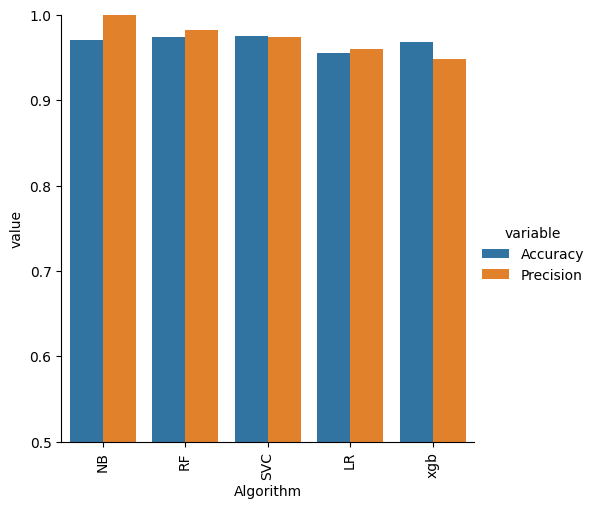

In [ ]:
sns.catplot(x = 'Algorithm', y='value',
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
display(performance_df_fbeta)

,Algorithm,Accuracy,Precision,Recall,F0.5_Score
1,NB,0.970986,1.000000,0.782609,0.947368
3,RF,0.973888,0.982609,0.818841,0.944816
0,SVC,0.975822,0.974790,0.840580,0.944625
4,xgb,0.968085,0.948718,0.804348,0.915842
2,LR,0.955513,0.960000,0.695652,0.892193




**Nhận xét tổng quan**:
- Hầu hết các mô hình đạt Accuracy > 95% — nhưng đây **không phải** chỉ số quan trọng nhất.
- **SVC** và **NB (MultinomialNB)** thường cho Precision cao nhất với TF-IDF.
- **KNN** thường có Precision thấp hơn do thuật toán dựa trên khoảng cách không hoạt động tốt với không gian đặc trưng thưa (sparse) của TF-IDF.
- **Ensemble methods** (RF, ETC, XGB) cải thiện Accuracy nhưng không nhất thiết cải thiện Precision.

Mô hình tốt nhất cho bài này = **Precision gần 1.0** + **Accuracy ổn định** + **F0.5 cao**.
